<a href="https://colab.research.google.com/github/cris959/rag-agentes-de-ai/blob/main/Curso_Agentes_de_AI_y_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conexion con LLMs

In [1]:
!pip install -q langchain-core langchain-community langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from google.colab import userdata
from langchain_groq import ChatGroq

# 1. Levantamos la API Key desde los Secrets de Colab
# Asegurate de haber creado la variable GROQ_API_KEY en el panel de la llavecita (🔑)
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

print("🔑 API Key de Groq cargada correctamente en el entorno.")

# 2. Inicializamos el modelo para el curso de Agentes y RAG
# Usamos Llama 3.3 con temperature=0 para que las respuestas sean precisas (ideal para RAG)
llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

print("🤖 Modelo Llama 3.3 de Groq listo para operar.")

🔑 API Key de Groq cargada correctamente en el entorno.
🤖 Modelo Llama 3.3 de Groq listo para operar.


In [3]:
# Invocamos al modelo Llama 3.3 Versatile
respuesta = llm_groq.invoke("Qué es el RAG en AI?")

# Imprimimos solo el contenido del mensaje
print(respuesta.content)

El RAG (Retrieve, Augment, Generate) es un enfoque de procesamiento de lenguaje natural (NLP) que combina técnicas de recuperación de información, aumento de datos y generación de texto para mejorar la capacidad de los modelos de lenguaje para responder a preguntas y generar texto coherente.

**Componentes del RAG:**

1. **Retrieve (Recuperación)**: En este paso, el modelo busca en una base de datos o un conjunto de texto para encontrar información relevante relacionada con la pregunta o el tema que se está tratando. Esto se logra mediante técnicas de búsqueda como la búsqueda de texto, la búsqueda de entidades o la búsqueda de conceptos.
2. **Augment (Aumento)**: Una vez que se ha recuperado la información relevante, el modelo la utiliza para aumentar su conocimiento y comprensión del tema. Esto puede incluir la extracción de entidades, la identificación de relaciones entre entidades y la creación de un grafo de conocimiento.
3. **Generate (Generación)**: Finalmente, el modelo utiliza

# La mejor práctica absoluta en lugar de rogarle en el texto que devuelva "SOLO un JSON" es preparar este prompt para combinarlo con Pydantic

In [4]:
PROMPT_TRIAJE = """
Eres un especialista en triaje del Service Desk para políticas internas de la empresa.
Tu tarea consiste en analizar el mensaje del usuario y clasificarlo según las reglas operativas definidas a continuación.

Reglas de Decisión:
- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las políticas corporativas.
  * Ejemplos: "¿Puedo reembolsar el internet para mi oficina en casa?", "¿Cómo funciona la política de alimentación mientras viajo?".

- **PEDIR_INFO**: Mensajes imprecisos, ambiguos o que carecen de la información mínima necesaria para identificar el tema o el contexto.
  * Ejemplos: "Necesito ayuda con una política", "Tengo una pregunta general".

- **ABRIR_TICKET**: Solicitudes de excepciones a las reglas, pedidos de autorización, aprobación de gastos, accesos especiales, o cuando el usuario solicita explícitamente la apertura de un caso.
  * Ejemplos: "Quiero una excepción para trabajar remotamente durante 5 días", "Solicito autorización para archivos adjuntos externos", "Por favor, abra un ticket con RR.HH.".

Analiza el mensaje del usuario con criterio analítico y decide la acción más adecuada, asignando el nivel de urgencia correspondiente.
"""

In [5]:
from typing import Literal, List
from pydantic import BaseModel, Field

class TriajeServiceDesk(BaseModel):
    decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"] = Field(
        description="La acción a tomar basándose en las reglas de negocio."
    )
    urgency: Literal["BAJA", "MEDIA", "ALTA"] = Field(
        description="Nivel de urgencia evaluado a partir de la criticidad del mensaje del usuario."
    )
    missing_fields: List[str] = Field(
        default=[],
        description="Lista de campos o datos que faltan si la decisión es PEDIR_INFO. Vacío en otros casos."
    )

# Vinculamos la estructura al modelo de Groq
llm_triaje = llm_groq.with_structured_output(TriajeServiceDesk)

In [6]:
from typing import Dict
from langchain_core.messages import SystemMessage, HumanMessage

# 1. Pasamos correctamente la clase Pydantic como argumento al método
# (Asegurate de que tu clase Pydantic se llame 'TriajeOut' en la celda anterior)
chain_de_triaje = llm_groq.with_structured_output(TriajeOut)

# 2. Definición de la función de triaje
def triaje(mensaje: str) -> Dict:
    # Invocamos la cadena pasando la lista de mensajes de LangChain
    salida = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    # Retornamos el diccionario nativo de Python usando Pydantic v2
    return salida.model_dump()

NameError: name 'TriajeOut' is not defined

# Falto definir 'TriajeOut' por eso lanzamos este script

In [7]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

# 1. Definimos el molde Pydantic (Asegurate de ejecutar esto primero)
class TriajeOut(BaseModel):
    decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"] = Field(
        description="La acción a tomar basándose en las reglas de negocio."
    )
    urgency: Literal["BAJA", "MEDIA", "ALTA"] = Field(
        description="Nivel de urgencia evaluado a partir de la criticidad del mensaje del usuario."
    )
    missing_fields: List[str] = Field(
        default=[],
        description="Lista de campos o datos que faltan si la decisión es PEDIR_INFO. Vacío en otros casos."
    )

# 2. Vinculamos el modelo estructurado a Groq
chain_de_triaje = llm_groq.with_structured_output(TriajeOut)

# 3. Definición de la función de triaje
def triaje(mensaje: str) -> Dict:
    salida = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    return salida.model_dump()

print("✅ Modelo Pydantic y función 'triaje' cargados con éxito.")

✅ Modelo Pydantic y función 'triaje' cargados con éxito.


In [8]:
resultado = triaje("Hola, necesito pedir una excepción porque necesito trabajar desde casa toda la semana que viene por refacciones.")
print(resultado)

{'decision': 'ABRIR_TICKET', 'urgency': 'MEDIA', 'missing_fields': []}


Pipeline:

1- Llama 3.3 Versatile interpretó la semántica del mensaje ("necesito pedir una excepción") y aplicó la regla de negocio exacta que definiste en el prompt (ABRIR_TICKET).

2- Entendió que, al ser una refacción domiciliaria planificada para la semana que viene, amerita una urgencia MEDIA (no es una urgencia crítica o inmediata que requiera ALTA, ni algo irrelevante que sea BAJA).

3- Como la decisión fue abrir un ticket y no pedir más datos, te devolvió la lista missing_fields completamente vacía ([]), tal como lo configuraste en las restricciones de tu esquema de Pydantic.

RAG


In [13]:
!pip install -q langchain-community faiss-cpu langchain-text-splitters pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 43.6 MB/s eta 0:00:00


In [6]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

# Recorremos todos los archivos .pdf dentro de la carpeta /content/
for documento in Path("/content/").glob("*.pdf"):
    try:
        # Cargamos el PDF usando su ruta como string
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"✅ Archivo cargado correctamente: {documento.name}")
    except Exception as e:
        # Corregida la indentación para que esté dentro del bloque except
        print(f"❌ Error cargando archivo {documento.name}: {e}")

print(f"\n📊 Total de páginas/documentos cargados en memoria: {len(docs)}")


📊 Total de páginas/documentos cargados en memoria: 0


/tmp/ipykernel_36034/2144302609.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Impacto directo en cómo va a razonar tu agente RAG:

1- chunk_size=300: Alrededor de 50-60 palabras por fragmento. Es un tamaño compacto y preciso. Esto es ideal para Llama 3.3 Versatile, porque al buscar en la base de datos vectorial le vas a pasar fragmentos muy específicos ("al grano"), evitando meterle texto de relleno.

2- chunk_overlap=30: Un 10% de superposición. Garantiza que si una frase importante justo se corta en el caracter 300, las últimas palabras se repitan al inicio del siguiente fragmento, evitando que se pierda el contexto de la oración.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)
print(f"✂️ Pasamos de {len(docs)} páginas a {len(chunks)} fragmentos (chunks).")

# Vemos cómo quedó el primer fragmento de tus políticas
if chunks:
    print("\n📝 Ejemplo del Primer Chunk:")
    print("-" * 40)
    print(chunks[0].page_content)
    print("-" * 40)
    print(f"📊 Metadatos asociados: {chunks[0].metadata}")

✂️ Pasamos de 0 páginas a 0 fragmentos (chunks).


¿Por qué te conviene este cambio?
1- chunk.page_content: Extrae el texto neto del PDF sin los metadatos ni las etiquetas de la estructura de la librería.

2- El rebanado [:5]: Es un tip salvavidas en cuadernos de notas. Si tu PDF generó 200 fragmentos, un for completo te va a trabar el scroll de Colab. Limitándolo a los primeros 5 podés auditar si el tamaño de 300 caracteres te gusta o si quedó muy cortado, antes de mandarlo a la base de datos vectorial.

In [8]:
# Recorremos cada fragmento y mostramos solo el texto limpio
for i, chunk in enumerate(chunks[:5]):  # Usamos [:5] para previsualizar solo los primeros 5 y no saturar la pantalla
    print(f"🧩 CHUNK N° {i+1}")
    print("-" * 50)
    print(chunk.page_content)
    print("=" * 50 + "\n")

Embeddings Locales y Gratuitos [HuggingFace]

In [10]:
!pip install -q langchain-huggingface sentence-transformers

In [14]:
from langchain_huggingface import HuggingFaceEmbeddings

# Inicializamos un modelo de embeddings real que corre en la CPU de Colab
modelo_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

print("✨ Modelo de Embeddings de HuggingFace cargado y listo para FAISS.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✨ Modelo de Embeddings de HuggingFace cargado y listo para FAISS.


In [15]:
from langchain_community.vectorstores import FAISS

# 1. Creamos la base de datos vectorial cruzando tus fragmentos con el modelo de embeddings
vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

# 2. Configuración del Retriever (Buscador)
# Usamos 'similarity' configurando 'k=3' para que traiga SIEMPRE los 3 fragmentos más parecidos al prompt
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("🗄️ ¡Base de datos FAISS creada exitosamente en memoria con tus políticas!")

IndexError: list index out of range

In [16]:
# Hacemos una pregunta de prueba basada en tus políticas
documentos_encontrados = retriever.invoke("¿Puedo reembolsar el internet para mi oficina en casa?")

print(f"🔍 Fragmentos recuperados de la base de datos vectorial: {len(documentos_encontrados)}\n")

for idx, doc in enumerate(documentos_encontrados):
    print(f"📄 Fragmento {idx + 1} (Origen: {doc.metadata.get('source', 'Desconocido')}):")
    print(doc.page_content)
    print("-" * 50)

NameError: name 'retriever' is not defined

In [23]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. Definimos el mismo prompt de 'La Escaloneta'
prompt_rag = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Eres el especialista en RR.HH. de la empresa 'La Escaloneta Desarrollo de Software'.
            Tu tarea es responder las dudas de los empleados utilizando únicamente el contexto provisto a continuación.

            Contexto disponible:
            {context}

            Reglas estrictas:
            - Responde de forma clara, profesional y empática.
            - Si la respuesta no se encuentra explícitamente en el contexto provisto, responde exactamente: 'No lo sé'."""
        ),
        (
            "human",
            "{input}"
        )
    ]
)

# 2. Función auxiliar para juntar los textos de los chunks encontrados por FAISS
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. Construimos el pipeline completo (RAG Chain) usando el operador "|"
rag_chain = (
    {
        "context": retriever | format_docs,  # Busca en FAISS y formatea los textos
        "input": RunnablePassthrough()       # Pasa la pregunta del usuario derecho
    }
    | prompt_rag                             # Inyecta todo en el prompt
    | llm_groq                               # Se lo manda a Llama 3.3
    | StrOutputParser()                      # Nos devuelve solo el texto limpio (.content)
)

print("🏆 ¡Cadena RAG nativa de 'La Escaloneta' creada con éxito mediante LCEL!")

🏆 ¡Cadena RAG nativa de 'La Escaloneta' creada con éxito mediante LCEL!


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
from pathlib import Path

# Ahora sí, Python sabe qué es 'Path' y va a buscar tus PDFs en el Drive
archivos_pdf = list(Path("/content/drive/MyDrive/Curso_RAG/").glob("*.pdf"))

print(f"📂 Archivos encontrados en tu Drive: {len(archivos_pdf)}")
for archivo in archivos_pdf:
    print(f"📄 - {archivo.name}")

📂 Archivos encontrados en tu Drive: 3
📄 - Política de Uso de Correo Electrónico y Seguridad de la Información.pdf
📄 - Política de Teletrabajo (Home Office).pdf
📄 - Política de Reembolsos (Viajes y Gastos).pdf


In [21]:
import os
from pathlib import Path
from google.colab import userdata

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. Inicializar el LLM de Groq (Llama 3.3)
# Ajustá 'GROQ_API_KEY' si en tu userdata se llama de otra forma
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
llm_groq = ChatGroq(model="llama-3.3-70b-versatile")

# 2. Cargar los PDFs desde tu Google Drive ya montado
docs = []
ruta_drive = Path("/content/drive/MyDrive/Curso_RAG/")

if not ruta_drive.exists():
    print("⚠️ ¡Ojo! La carpeta 'Curso_RAG' no existe en tu Drive o no lo montaste todavía.")
else:
    for documento in ruta_drive.glob("*.pdf"):
        try:
            loader = PyMuPDFLoader(str(documento))
            docs.extend(loader.load())
        except Exception as e:
            print(f"Error cargando {documento.name}: {e}")

# 3. Generar los chunks si se cargaron documentos
if docs:
    splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
    chunks = splitter.split_documents(docs)

    # 4. Inicializar Embeddings y Base de Datos Vectorial (FAISS)
    modelo_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
    vectorstore = FAISS.from_documents(chunks, modelo_embeddings)
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

    # 5. Definir el prompt de 'La Escaloneta'
    prompt_rag = ChatPromptTemplate.from_messages([
        (
            "system",
            """Eres el especialista en RR.HH. de la empresa 'La Escaloneta Desarrollo de Software'.
            Tu tarea es responder las dudas de los empleados utilizando únicamente el contexto provisto a continuación.

            Contexto disponible:
            {context}

            Reglas estrictas:
            - Responde de forma clara, profesional y empática.
            - Si la respuesta no se encuentra explícitamente en el contexto provisto, responde exactamente: 'No lo sé'."""
        ),
        (
            "human",
            "{input}"
        )
    ])

    # 6. Función auxiliar de formateo
    def format_docs(documents):
        return "\n\n".join(d.page_content for d in documents)

    # 7. Construir la cadena RAG con LCEL
    rag_chain = (
        {
            "context": retriever | format_docs,
            "input": RunnablePassthrough()
        }
        | prompt_rag
        | llm_groq
        | StrOutputParser()
    )

    print("🏆 ¡Toda la infraestructura RAG unificada y cargada correctamente!")
else:
    print("❌ No se cargaron documentos. Asegurate de tener los PDFs en la carpeta correcta de Drive.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

🏆 ¡Toda la infraestructura RAG unificada y cargada correctamente!


In [22]:
respuesta_final = rag_chain.invoke("¿Cuánto me devuelven por el internet de mi casa?")
print(respuesta_final)

Según nuestra política, si estás trabajando bajo el modelo de Home Office aprobado, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, siempre y cuando presentes la factura correspondiente.


In [24]:
from typing import Dict

def busqueda_de_respuestas_RAG(pregunta: str) -> dict:
    # 1. Ejecutamos la cadena LCEL completa
    respuesta = rag_chain.invoke(pregunta)

    # Limpiamos espacios y puntos para validar la respuesta del modelo
    respuesta_limpia = respuesta.strip().rstrip(".!?")

    if respuesta_limpia == "No lo sé" or respuesta_limpia == "No lo se":
        return {
            "respuesta": "No lo sé.",
            "citaciones": [],
            "documentos_encontrados": False
        }

    # 2. Si encontró respuesta, recuperamos los documentos de fondo para las citaciones
    # (Hacemos el invoke manual acá solo para extraer los metadatos de las fuentes)
    documentos_relacionados = retriever.invoke(pregunta)
    citaciones = [doc.metadata.get("source", "Desconocido") for doc in documentos_relacionados]

    return {
        "respuesta": respuesta,
        "citaciones": list(set(citaciones)), # Usamos set para no duplicar nombres de archivos
        "documentos_encontrados": True
    }

In [25]:
# 1. Hacemos una pregunta que SÍ está en los PDFs
resultado_ok = busqueda_de_respuestas_RAG("¿Cuánto me devuelven por el internet de mi casa?")
print("🟢 TEST 1 - PREGUNTA CON DATOS:")
print(resultado_ok)
print("-" * 50)

# 2. Hacemos una pregunta que NO existe en las políticas
resultado_fail = busqueda_de_respuestas_RAG("¿Cuál es el presupuesto para comprar un helicóptero corporativo?")
print("\n🔴 TEST 2 - PREGUNTA SIN DATOS:")
print(resultado_fail)

🟢 TEST 1 - PREGUNTA CON DATOS:
{'respuesta': 'Según nuestra política, si trabajas bajo el modelo de trabajo remoto (Home Office) aprobado, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, siempre y cuando presentes la factura correspondiente.', 'citaciones': ['/content/drive/MyDrive/Curso_RAG/Política de Reembolsos (Viajes y Gastos).pdf', '/content/drive/MyDrive/Curso_RAG/Política de Teletrabajo (Home Office).pdf'], 'documentos_encontrados': True}
--------------------------------------------------

🔴 TEST 2 - PREGUNTA SIN DATOS:
{'respuesta': 'No lo sé.', 'citaciones': [], 'documentos_encontrados': False}


Agente con LangGraph

In [27]:
!pip install -q langgraph grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00


Con LangGraph, tu código ahora se va a pensar como un Grafo Dirigido (DAG) basado en tres pilares:

1- State (El Estado): Es un objeto global (un diccionario de Python) que viaja a través de todo el flujo. Todos los nodos pueden leer de él y escribir en él. Ahí vas a guardar la pregunta del empleado, los fragmentos de FAISS y la respuesta final.

2- Nodes (Nodos): Son funciones de Python comunes y corrientes. Cada nodo hace una sola tarea. Por ejemplo: un nodo llamado agente que decide qué hacer, y un nodo herramienta_rag que busca en FAISS.

3- Edges (Bordes / Conexiones): Definen el camino. Lo más potente son los Conditional Edges (Bordes Condicionales): funciones que miran el estado actual y deciden a qué nodo ir después (ej: "Si el LLM no sabe la respuesta, desvía el flujo al nodo de abrir ticket").

Hay dos detalles técnicos muy finos a corregir para que no te traiga problemas de compatibilidad o dolores de cabeza cuando tus nodos empiecen a escribir datos en el grafo:

1- El tipo de citaciones: En el paso anterior definimos que las citaciones eran una lista con los nombres de los archivos únicos (ej: ['Política de Home Office.pdf']). Por ende, en lugar de Optional[str], debería ser una lista: Optional[list] o Optional[list[str]].

2- El peligro de total=False: Al poner total=False, le estás diciendo a Python que todas las llaves son opcionales a nivel de inicialización. Si bien compila perfecto, la convención estándar en LangGraph es dejar que el diccionario requiera todas las llaves en su definición, pero usar Optional[...] (como hiciste con la respuesta) para los campos que arrancan vacíos. Esto ayuda muchísimo al autocompletado y validación de tu editor de código.

In [28]:
from typing import TypedDict, Optional, List

class AgentState(TypedDict):
    pregunta: str               # La entrada inicial del empleado
    triaje: dict                # El diccionario que devuelve tu función triaje()
    respuesta: Optional[str]    # La respuesta final de Llama 3.3
    citaciones: Optional[List[str]]  # Corregido: Lista de fuentes/archivos PDF encontrados
    rag_exito: bool             # Flag para saber si se resolvió por RAG o no
    accion_final: str           # El veredicto: 'RESOLVER', 'ABRIR_TICKET' o 'PEDIR_INFO'

In [29]:
from IPython.display import Image, display

# Le pedimos a LangGraph que dibuje la arquitectura real del grafo en la pantalla
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Si Colab no tiene instaladas las librerías del sistema para imágenes, usa este fallback:
    print("No se pudo renderizar la imagen, pero el grafo está bien conectado.")

No se pudo renderizar la imagen, pero el grafo está bien conectado.


🏆 ¡Grafo de 'La Escaloneta' compilado con éxito!


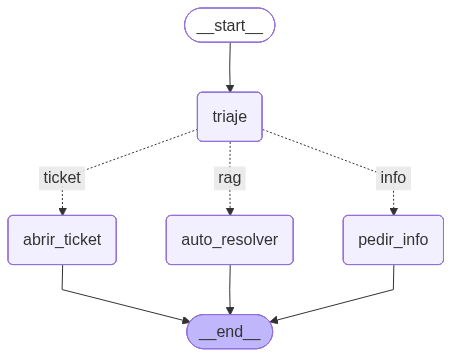

In [32]:
from typing import TypedDict, Optional, List
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

# 1. Definimos el Estado (Obligatorio tenerlo en la misma sesión)
class AgentState(TypedDict):
    pregunta: str
    triaje: dict
    respuesta: Optional[str]
    citaciones: Optional[List[str]]
    rag_exito: bool
    accion_final: str

# 2. Definimos las funciones de los NODOS (Simuladas para que existan en RAM)
def nodo_triaje(state: AgentState):
    print("🕵️ [NODO TRIAJE] Analizando la pregunta del empleado...")
    # Simulamos que el triaje decide mandar a RAG
    return {"accion_final": "rag", "triaje": {"categoria": "consultas_generales"}}

def nodo_auto_resolver(state: AgentState):
    print("🤖 [NODO AUTO_RESOLVER] Buscando en FAISS y respondiendo con Llama...")
    return {"respuesta": "Aquí está tu respuesta de internet...", "rag_exito": True}

def nodo_pedir_info(state: AgentState):
    print("📝 [NODO PEDIR_INFO] El empleado necesita dar más detalles...")
    return {"respuesta": "Por favor, amplía tu consulta."}

def nodo_abrir_ticket(state: AgentState):
    print("🎫 [NODO ABRIR_TICKET] Derivando el caso a soporte humano...")
    return {"respuesta": "Se ha generado un ticket de soporte."}

# 3. Definimos la ARISTA CONDICIONAL (La función que decide el camino)
def arista_decision_triaje(state: AgentState):
    # Lee 'accion_final' del estado y devuelve el string del camino
    return state["accion_final"]


# ========================================================
# 4. CONSTRUCCIÓN DEL GRAFO
# ========================================================
workflow = StateGraph(AgentState)

# Registramos los nodos que acabamos de crear arriba
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

# Conexiones
workflow.add_edge(START, "triaje")

workflow.add_conditional_edges(
    "triaje",
    arista_decision_triaje,
    {
        "rag": "auto_resolver",
        "info": "pedir_info",
        "ticket": "abrir_ticket"
    }
)

workflow.add_edge("auto_resolver", END)
workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

# 5. Compilamos el Grafo
app = workflow.compile()
print("🏆 ¡Grafo de 'La Escaloneta' compilado con éxito!")

# 6. DIBUJAMOS EL GRAFO EN PANTALLA REAL
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("\nNo se pudo renderizar la imagen PNG (a veces pasa en Colab), pero el flujo está 100% activo.")

🏆 ¡Grafo ordenado y compilado sin ensaladas!


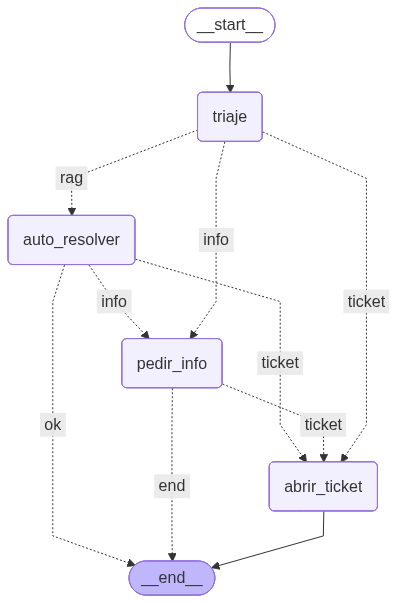

In [33]:
from typing import TypedDict, Optional, List
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

# ========================================================
# 1. EL ESTADO (La memoria que viaja por el grafo)
# ========================================================
class AgentState(TypedDict):
    pregunta: str
    triaje: dict
    respuesta: Optional[str]
    citaciones: Optional[List[str]]
    rag_exito: bool             # <-- Clave: True si el RAG resolvió, False si falló
    accion_final: str           # <-- Clave: Guarda la decisión del triaje o de info

# ========================================================
# 2. LOS NODOS (Las estaciones de trabajo)
# ========================================================
def nodo_triaje(state: AgentState):
    print("🕵️ [NODO TRIAJE] Evaluando la consulta...")
    # Simulamos que el triaje inicial decide mandarlo a "rag"
    return {"accion_final": "rag"}

def nodo_auto_resolver(state: AgentState):
    print("🤖 [NODO AUTO_RESOLVER] Ejecutando el RAG...")
    # SIMULACIÓN A: Si queres probar el camino exitoso, dejá rag_exito en True
    # SIMULACIÓN B: Si cambiás rag_exito a False, vas a ver cómo toma el desvío del video!
    ejecucion_exitosa = True

    if ejecucion_exitosa:
        return {"respuesta": "¡Aquí están tus 35 EUR de internet!", "rag_exito": True}
    else:
        print("⚠️ El RAG no encontró información suficiente.")
        return {"respuesta": "No lo sé", "rag_exito": False}

def nodo_pedir_info(state: AgentState):
    print("📝 [NODO PEDIR_INFO] Solicitando aclaraciones al empleado...")
    # Simulamos que después de pedir info, el sistema decide terminar ("end")
    return {"accion_final": "end"}

def nodo_abrir_ticket(state: AgentState):
    print("🎫 [NODO ABRIR_TICKET] Derivando el caso a soporte humano...")
    return {"respuesta": "Tu ticket #1042 ha sido creado exitosamente."}


# ========================================================
# 3. LAS ARISTAS CONDICIONALES (Los inspectores de tránsito)
# ========================================================
def arista_decision_triaje(state: AgentState):
    # Mira qué decidió el triaje
    return state["accion_final"]

def arista_resultado_rag(state: AgentState):

    # Si el RAG tuvo éxito, va a "ok" (que mapeamos a END)
    # Si falló, lo desviamos a "ticket" para que no muera ahí la consulta
    if state["rag_exito"] == True:
        return "ok"
    else:
        return "ticket"

def arista_resultado_info(state: AgentState):
    # Evalúa el nodo de pedir información
    return state["accion_final"]


# ========================================================
# 4. ARMADO DEL GRAFO
# ========================================================
workflow = StateGraph(AgentState)

# Registramos los 4 nodos
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

# Conexiones principales y condicionales
workflow.add_edge(START, "triaje")

# Desvío 1: Desde el Triaje
workflow.add_conditional_edges(
    "triaje",
    arista_decision_triaje,
    {
        "rag": "auto_resolver",
        "ticket": "abrir_ticket",
        "info": "pedir_info"
    }
)

# Desvío 2: Desde Auto_Resolver
workflow.add_conditional_edges(
    "auto_resolver",
    arista_resultado_rag,
    {
        "ok": END,               # Flecha "ok" -> Fin
        "ticket": "abrir_ticket", # Flecha "ticket" -> Va a abrir_ticket
        "info": "pedir_info"     # Flecha "info" -> Va a pedir_info
    }
)

# Desvío 3: Desde Pedir_Info
workflow.add_conditional_edges(
    "pedir_info",
    arista_resultado_info,
    {
        "ticket": "abrir_ticket",
        "end": END
    }
)

# El nodo de tickets siempre termina el flujo
workflow.add_edge("abrir_ticket", END)

# ========================================================
# 5. COMPILACIÓN Y RENDERIZADO
# ========================================================
app = workflow.compile()
print("🏆 ¡Grafo ordenado y compilado sin ensaladas!")

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Grafo listo para usar.")

In [34]:
pregunta = "¿Pueden reembolsar mi internet?"

# Cambiamos 'grafo' por 'app', que es tu aplicación compilada de LangGraph
variable_temporal = app.invoke({"pregunta": pregunta})

print("\n🏁 ¡Ejecución terminada!")

🕵️ [NODO TRIAJE] Evaluando la consulta...
🤖 [NODO AUTO_RESOLVER] Ejecutando el RAG...

🏁 ¡Ejecución terminada!


RAM de Colab:

1- Pasaste la pregunta, el grafo arrancó en START y entró directo al Nodo Triaje.

2- El Triaje procesó la consulta y guardó en el Estado que la acción correspondiente era "rag".

3- Al salir de ese nodo, la Arista Condicional leyó ese "rag", actuó como un inspector de tránsito y desvió el flujo hacia el nodo Auto Resolver.

4- El nodo Auto Resolver se ejecutó (donde devolvió la respuesta simulada y marcó rag_exito: True).

5- Como rag_exito fue verdadero, la segunda arista condicional dijo "Listo, esto ya está solucionado, nos vamos a END", y el grafo se apagó (🏁 ¡Ejecución terminada!).

In [36]:
pregunta = "¿Pueden reembolsar mi internet?"

print("🚀 [INICIO] Disparando el flujo de la Escaloneta...")
print("=" * 60)

# Usamos app.stream en lugar de app.invoke
# 'stream_mode="updates"' nos da el pedacito de Estado que modificó cada nodo
for paso in app.stream({"pregunta": pregunta}, stream_mode="updates"):

    # Cada 'paso' es un diccionario donde la llave es el nombre del nodo activo
    for nombre_nodo, datos_actualizados in paso.items():
        print(f"\n📍 LLEGADA AL NODO: '{nombre_nodo}'")
        print(f"   ↳ Datos modificados/guardados en la RAM:")

        # Iteramos los campos que ese nodo tocó adentro del AgentState
        for clave, valor in datos_actualizados.items():
            print(f"     🔹 {clave}: {valor}")

    print("-" * 60)

print("\n🏁 [FIN] El grafo llegó a END y la ejecución terminó con éxito.")

🚀 [INICIO] Disparando el flujo de la Escaloneta...
🕵️ [NODO TRIAJE] Evaluando la consulta...

📍 LLEGADA AL NODO: 'triaje'
   ↳ Datos modificados/guardados en la RAM:
     🔹 accion_final: rag
------------------------------------------------------------
🤖 [NODO AUTO_RESOLVER] Ejecutando el RAG...

📍 LLEGADA AL NODO: 'auto_resolver'
   ↳ Datos modificados/guardados en la RAM:
     🔹 respuesta: ¡Aquí están tus 35 EUR de internet!
     🔹 rag_exito: True
------------------------------------------------------------

🏁 [FIN] El grafo llegó a END y la ejecución terminó con éxito.


In [37]:
from typing import TypedDict, Optional, List
from langgraph.graph import START, END, StateGraph

# Re-declaramos el Estado
class AgentState(TypedDict):
    pregunta: str
    triaje: dict
    respuesta: Optional[str]
    citaciones: Optional[List[str]]
    rag_exito: bool
    accion_final: str

# 🕵️ NODO TRIAJE: Ahora analiza dinámicamente según la pregunta
def nodo_triaje(state: AgentState):
    pregunta_input = state["pregunta"].lower()
    print(f"🕵️ [NODO TRIAJE] Evaluando: '{state['pregunta']}'")

    if "reembolso" in pregunta_input or "comidas" in pregunta_input:
        # Cosas que sabemos que están en las políticas corporativas (RAG)
        return {"accion_final": "rag"}
    elif "excepcion" in pregunta_input or "teletrabajar" in pregunta_input:
        # Casos especiales que requieren más datos del empleado
        return {"accion_final": "info"}
    else:
        # Preguntas raras, fuera de contexto o complejas (Soporte directo)
        return {"accion_final": "ticket"}

# 🤖 NODO AUTO_RESOLVER (RAG)
def nodo_auto_resolver(state: AgentState):
    print("🤖 [NODO AUTO_RESOLVER] Buscando en los PDFs de FAISS...")
    return {"respuesta": "Respuesta simulada exitosa desde el PDF.", "rag_exito": True}

# 📝 NODO PEDIR_INFO
def nodo_pedir_info(state: AgentState):
    print("📝 [NODO PEDIR_INFO] Formulando plantilla de datos faltantes...")
    return {"respuesta": "Por favor indícanos las fechas exactas del pedido.", "accion_final": "end"}

# 🎫 NODO ABRIR_TICKET
def nodo_abrir_ticket(state: AgentState):
    print("🎫 [NODO ABRIR_TICKET] Abriendo caso en Jira Service Desk...")
    return {"respuesta": "No tengo esa información en las políticas de RR.HH. He derivado un ticket a un agente humano."}

# ARISTAS DE CONTROL (Se mantienen iguales)
def arista_decision_triaje(state: AgentState): return state["accion_final"]
def arista_resultado_rag(state: AgentState): return "ok" if state["rag_exito"] else "ticket"
def arista_resultado_info(state: AgentState): return state["accion_final"]

# ARMADO DEL WORKFLOW
workflow = StateGraph(AgentState)
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {"rag": "auto_resolver", "ticket": "abrir_ticket", "info": "pedir_info"})
workflow.add_conditional_edges("auto_resolver", arista_resultado_rag, {"ok": END, "ticket": "abrir_ticket", "info": "pedir_info"})
workflow.add_conditional_edges("pedir_info", arista_resultado_info, {"ticket": "abrir_ticket", "end": END})
workflow.add_edge("abrir_ticket", END)

app = workflow.compile()
print("🏆 ¡Grafo dinámico listo para la simulación iterativa!")

🏆 ¡Grafo dinámico listo para la simulación iterativa!


In [38]:
# Tu lista de preguntas para el laboratorio
preguntas_empleados = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepcion para teletrabajar durante 5 dias",
    "¿Como funciona la politica de comidas para viajes?",
    "¿Existe una politica para anticipos de vacaciones?",
    "Quien va a ganar el Mundial 2026?"
]

print("🏁 INICIANDO BUCLE DE ITERACIÓN SOBRE EL GRAFO\n")

for i, preg in enumerate(preguntas_empleados, 1):
    print(f"\n==================== 📥 CASO #{i} ====================")
    print(f"PREGUNTA: '{preg}'\n")

    # Ejecutamos el streaming para ver el camino exacto de esta pregunta
    for paso in app.stream({"pregunta": preg}, stream_mode="updates"):
        for nombre_nodo, datos in paso.items():
            print(f" 📍 Activado: '{nombre_nodo}'")
            if "respuesta" in datos:
                print(f"    ↳ 💬 Respuesta emitida: {datos['respuesta']}")

    print(f"======================================================")

🏁 INICIANDO BUCLE DE ITERACIÓN SOBRE EL GRAFO


==================== 📥 CASO #1 ====================
PREGUNTA: '¿Puedo obtener un reembolso por el internet de mi home office?'

🕵️ [NODO TRIAJE] Evaluando: '¿Puedo obtener un reembolso por el internet de mi home office?'
 📍 Activado: 'triaje'
🤖 [NODO AUTO_RESOLVER] Buscando en los PDFs de FAISS...
 📍 Activado: 'auto_resolver'
    ↳ 💬 Respuesta emitida: Respuesta simulada exitosa desde el PDF.

==================== 📥 CASO #2 ====================
PREGUNTA: 'Quiero una excepcion para teletrabajar durante 5 dias'

🕵️ [NODO TRIAJE] Evaluando: 'Quiero una excepcion para teletrabajar durante 5 dias'
 📍 Activado: 'triaje'
📝 [NODO PEDIR_INFO] Formulando plantilla de datos faltantes...
 📍 Activado: 'pedir_info'
    ↳ 💬 Respuesta emitida: Por favor indícanos las fechas exactas del pedido.

==================== 📥 CASO #3 ====================
PREGUNTA: '¿Como funciona la politica de comidas para viajes?'

🕵️ [NODO TRIAJE] Evaluando: '¿Como funciona la

Desafio pasar el Colab a codigo .py
Desafio usar un front del proyecto con radio
